In [1]:
import arviz as az
import os.path as op
from utils import get_data
import numpy as np
import matplotlib.pyplot as plt

bids_folder = '/Users/mrenke/data/ds-stressrisk'

model_folder = op.join(bids_folder, 'derivatives', 'cogmodels')
df = get_data().set_index('group', append=True)
group_mapping = df.groupby(['subject', 'group']).size().reset_index(['group']).drop(0, axis=1)

n_model = 1
idata= az.from_netcdf(op.join(model_folder, f'model-{n_model}_trace.netcdf'))


/Users/mrenke/mambaforge/envs/behav_fit2/lib/python3.10/site-packages/nilearn/glm/__init__.py:55: FutureWarning: The nilearn.glm module is experimental. It may change in any future release of Nilearn.
  warn('The nilearn.glm module is experimental. '
/Users/mrenke/mambaforge/envs/behav_fit2/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
objective_risky_mu = np.log(df.groupby(['subject'])['n_risky'].mean())

In [3]:
risky_prior_mu_post = idata.posterior['risky_prior_mu'].to_dataframe()
risky_prior_mu_post = risky_prior_mu_post.join(group_mapping).set_index('group', append=True)

In [8]:
import seaborn as sns
prior_mu_ses1_group0 = risky_prior_mu_post.xs('Intercept', 0, 'risky_prior_mu_regressors')
prior_mu_ses2_group0 = risky_prior_mu_post.xs('Intercept', 0, 'risky_prior_mu_regressors') + risky_prior_mu_post.xs('session', 0, 'risky_prior_mu_regressors')
prior_mu_ses1_group1 = risky_prior_mu_post.xs('Intercept', 0, 'risky_prior_mu_regressors') + risky_prior_mu_post.xs('group', 0, 'risky_prior_mu_regressors')
prior_mu_ses2_group1 = risky_prior_mu_post.xs('Intercept', 0, 'risky_prior_mu_regressors') + risky_prior_mu_post.xs('group', 0, 'risky_prior_mu_regressors') + risky_prior_mu_post.xs('session', 0, 'risky_prior_mu_regressors') + risky_prior_mu_post.xs('session:group', 0, 'risky_prior_mu_regressors')

prior_mu_ses1_group0 = prior_mu_ses1_group0.xs(0, 0, 'group')
prior_mu_ses2_group0 = prior_mu_ses2_group0.xs(0, 0, 'group')

prior_mu_ses1_group1 = prior_mu_ses1_group1.xs(1, 0, 'group')
prior_mu_ses2_group1 = prior_mu_ses2_group1.xs(1, 0, 'group')


/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_67376/436947616.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(diff_objective_subjective_ses1_group0)
/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_67376/436947616.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dif

<AxesSubplot: ylabel='Density'>

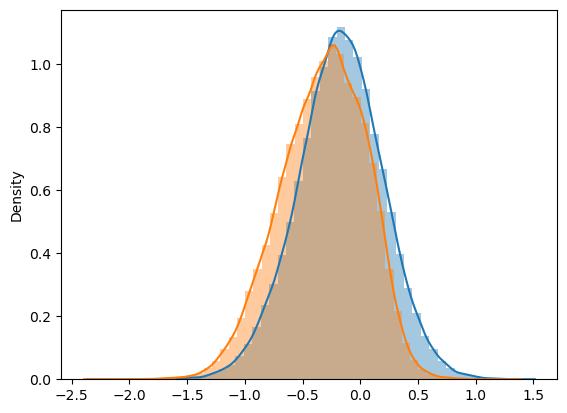

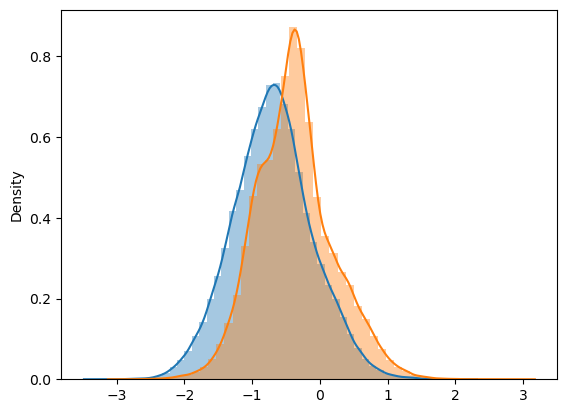

In [31]:
diff_objective_subjective_ses1_group0 = prior_mu_ses1_group0['risky_prior_mu'] - objective_risky_mu
diff_objective_subjective_ses2_group0 = prior_mu_ses2_group0['risky_prior_mu'] - objective_risky_mu
diff_objective_subjective_ses1_group1 = prior_mu_ses1_group1['risky_prior_mu'] - objective_risky_mu
diff_objective_subjective_ses2_group1 = prior_mu_ses2_group1['risky_prior_mu'] - objective_risky_mu
sns.distplot(diff_objective_subjective_ses1_group0)
sns.distplot(diff_objective_subjective_ses2_group0)

plt.figure()
sns.distplot(diff_objective_subjective_ses1_group1)
sns.distplot(diff_objective_subjective_ses2_group1)

/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_67376/547379540.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(diff_of_diff_group0)
/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_67376/547379540.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(diff_of_diff_group1)


<AxesSubplot: ylabel='Density'>

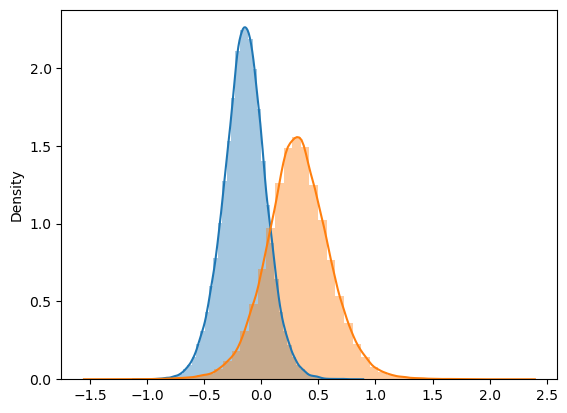

In [32]:
diff_of_diff_group0 = diff_objective_subjective_ses2_group0 - diff_objective_subjective_ses1_group0
diff_of_diff_group1 = diff_objective_subjective_ses2_group1 - diff_objective_subjective_ses1_group1


sns.distplot(diff_of_diff_group0)
sns.distplot(diff_of_diff_group1)
# diff_of_diff = diff_of_diff.groupby(['chain', 'draw']).mean()
# sns.distplot(diff_of_diff)

/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_67376/3963165742.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(diff_of_diff_group0.groupby(['chain', 'draw']).mean() - diff_of_diff_group1.groupby(['chain', 'draw']).mean())


<AxesSubplot: ylabel='Density'>

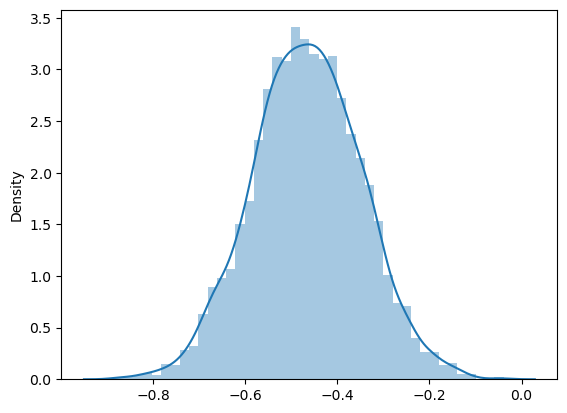

In [34]:
sns.distplot(diff_of_diff_group0.groupby(['chain', 'draw']).mean() - diff_of_diff_group1.groupby(['chain', 'draw']).mean())

In [36]:
final_diff = diff_of_diff_group0.groupby(['chain', 'draw']).mean() - diff_of_diff_group1.groupby(['chain', 'draw']).mean()

(final_diff > 0.0).mean()

0.0

/Users/mrenke/mambaforge/envs/behav_fit2/lib/python3.10/site-packages/seaborn/axisgrid.py:848: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  func(*plot_args, **plot_kwargs)
/Users/mrenke/mambaforge/envs/behav_fit2/lib/python3.10/site-packages/seaborn/axisgrid.py:848: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  func(*pl

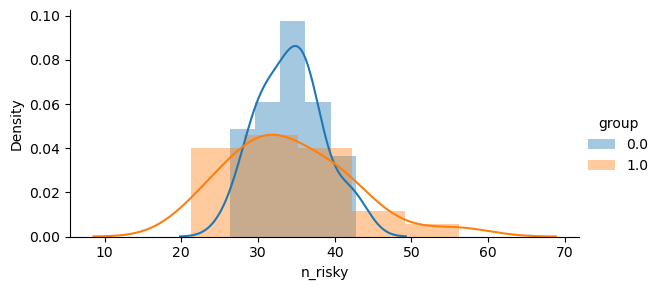

In [22]:
fac = sns.FacetGrid(df.groupby(['subject', 'group'])[['n_risky']].mean().reset_index(), hue='group', aspect=2.)

fac.map(sns.distplot, 'n_risky')
fac.add_legend()

In [9]:
diff_objective_subjective

risky_prior_mu   1   2   3   4   5   9  10  12  13  ...  \
chain draw subject                                                      ...   
0     0    1                   NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
           2                   NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
           3                   NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
           4                   NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
           5                   NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
...                            ...  ..  ..  ..  ..  ..  ..  ..  ..  ..  ...   
3     999  55                  NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
           57                  NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
           58                  NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
           59                  NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   
           61                  NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...   

                    50  51  52  53  54  55  57  58  59  61  
chain draw subject                                          
0     0    1       NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  
           2       NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  
           3       NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  
           4       NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  
           5       NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  
...                 ..  ..  ..  ..  ..  ..  ..  ..  ..  ..  
3     999  55      NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  
           57      NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  
           58      NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  
           59      NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  
           61      NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  

[200000 rows x 51 columns]

In [6]:
session2 = risky_prior_mu_post.xs('Intercept', 0, 'risky_prior_mu_regressors') + risky_prior_mu_post.xs('session', 0, 'risky_prior_mu_regressors') + risky_prior_mu_post.xs('Intercept', 0, 'risky_prior_mu_regressors') + risky_prior_mu_post.xs('group', 0, 'risky_prior_mu_regressors')

risky_prior_mu
chain draw subject                
0     0    1              6.220962
           2              6.430643
           3              6.236626
           4              6.026185
           5              6.338274
...                            ...
3     999  55             7.395538
           57             4.854034
           58             5.524493
           59             5.744794
           61             5.855991

[200000 rows x 1 columns]

In [5]:
risky_prior_mu_post.xs('session', 0, 'risky_prior_mu_regressors').groupby('subject').mean()

,risky_prior_mu
subject,
1,-0.059489
2,-0.037181
3,-0.153759
4,-0.127061
5,-0.057227
9,-0.275947
10,-0.171761
12,-0.153637
13,-0.179595
